### Exploración Inicial de Datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('StudentsPerformance.csv')

In [2]:
print(df.shape[0])
print(df.shape[1])
print(df.columns.tolist())
print(df.dtypes)
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())

1000
8
['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']
gender                         object
race/ethnicity                 object
parental level of education    object
lunch                          object
test preparation course        object
math score                      int64
reading score                   int64
writing score                   int64
dtype: object
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
0
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.

### Creación de variables y clasificación
Criterios utilizados para las categorías:
- Bajo: Promedio menor a 60, lo cual indica un rendimiento deficiente que requiere atención prioritaria.
- Medio: Promedio de 60 a 79.99, refleja un rendimiento regular, aceptable pero con margen de mejora.
- Alto: Promedio de 80 o superior, destaca un rendimiento sobresaliente dominando las tres áreas evaluadas.

In [4]:
df['average_score'] = df[['math score', 'reading score', 'writing score']].mean(axis=1)

def clasificar_rendimiento(promedio):
    if promedio < 60:
        return 'Bajo'
    elif promedio < 80:
        return 'Medio'
    else:
        return 'Alto'

df['rendimiento'] = df['average_score'].apply(clasificar_rendimiento)

### Análisis de Datos
Preguntas a responder:
1. ¿Cuál de las tres áreas tiene el promedio más alto?
2. ¿Los estudiantes que realizaron el curso de preparación presentan mejores resultados?
3. ¿Existen diferencias en el rendimiento según el nivel educativo de los padres?
4. ¿Qué grupos presentan los promedios más altos y más bajos?

In [6]:
print(df[['math score', 'reading score', 'writing score']].mean())
print(df.groupby('test preparation course')['average_score'].mean())
print(df.groupby('parental level of education')['average_score'].mean().sort_values())
print(df.groupby('race/ethnicity')['average_score'].mean().sort_values())

math score       66.089
reading score    69.169
writing score    68.054
dtype: float64
test preparation course
completed    72.669460
none         65.038941
Name: average_score, dtype: float64
parental level of education
high school           63.096939
some high school      65.108007
some college          68.476401
associate's degree    69.569069
bachelor's degree     71.923729
master's degree       73.598870
Name: average_score, dtype: float64
race/ethnicity
group A    62.992509
group B    65.468421
group C    67.131661
group D    69.179389
group E    72.752381
Name: average_score, dtype: float64


### Visualizaciones

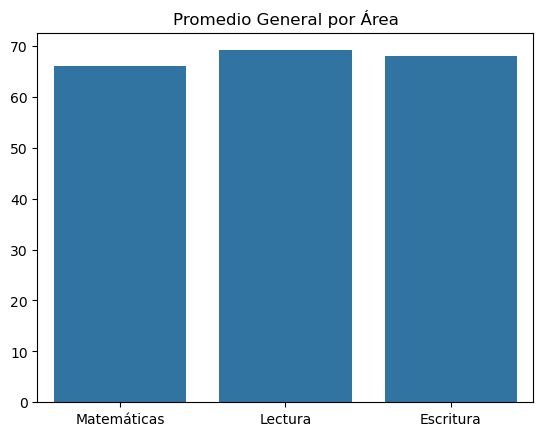

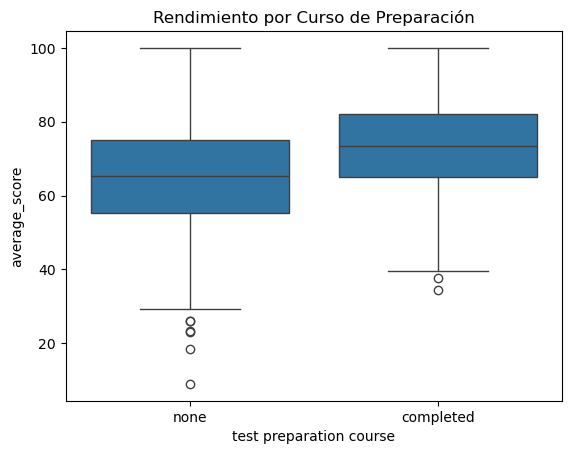

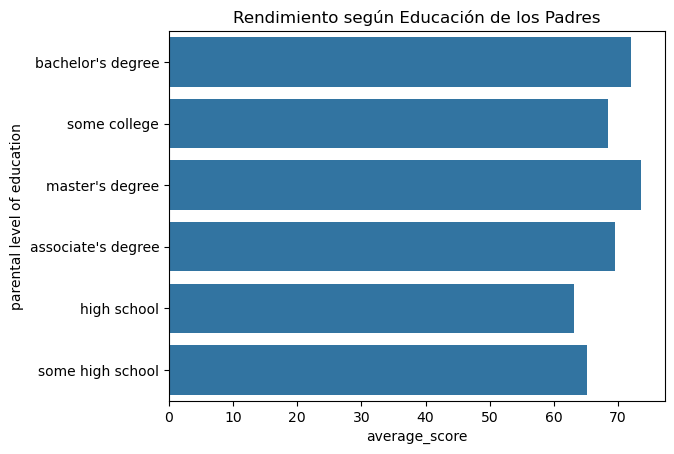

In [7]:
sns.barplot(x=['Matemáticas', 'Lectura', 'Escritura'], y=df[['math score', 'reading score', 'writing score']].mean().values)
plt.title('Promedio General por Área')
plt.show()

sns.boxplot(x='test preparation course', y='average_score', data=df)
plt.title('Rendimiento por Curso de Preparación')
plt.show()

sns.barplot(y='parental level of education', x='average_score', data=df, errorbar=None)
plt.title('Rendimiento según Educación de los Padres')
plt.show()

### Conclusiones
- El área de lectura cuenta con el promedio más alto general de 69.16 de las tres áreas analizadas.
- Efectivamente, los estudiantes que completaron el curso de preparación tienen un mejor promedio de 72.66 contra 65.03 de los que no lo tomaron.
- Hay una relación evidente donde los hijos de padres con grados universitarios y maestrías obtienen los mejores resultados promedios por encima de 71, superando con creces a aquellos con niveles educativos correspondientes únicamente a preparatoria.
- El grupo E es el de mayor rendimiento con un promedio de 72.75, mientras que el grupo A presenta los promedios más bajos con 62.99.